---
title: "Density Plots"
subtitle: "DS 2023 | Communicating with Data"
---

<img src="https://virginia.box.com/shared/static/18bic5a77gpd1011x47lj870elx38hgo.png" style="width:500px;"/>

## Overview

A density plot is something like a **continuous version of a histogram**. 

Like a histogram, it represents the distribution of a continuous variable. 

But instead of using binning and counting, it estimates **a probability density function** using more sophisticated methods, such as kernel estimation.

A density plot may be thought of as a special case of a line graph where the x axis represents an increasing numeric value, and the y axis represents an estimate or frequency. 

However, the density plot does not represent a trend. Instead, it is more like the function use case.

Like line graphs, they may also be rendered as area charts to show accumulation.

## Use Cases

Like histograms, density plots provide a quick way to inspect the centrality and dispersion of a distribution.

They allow you to inspect the shape of a distribution for modality, skew, and kurtosis.

They can also surface outliers and mutliple populations.

Beyond histograms, density plots are more opiniated, as it were, in suggesting a function behind the empirical distribution. 

Instead of showing counts, it shows the denstity of data points within a given range. 

Density plots are particularly useful for larger datasets.

## Creating a density plot from scratch

Density plots are construced using a method called **kernel density estimation** (KDE). 

Hence their being called KDE plots, as in Pandas (see below).

The image below gives a good idea of how they are constructed.

For data point, a gaussian distribution is generated. These are the kernels.

Then, these kernels are added up to produce the emergent curve.

In practice the algorithm may be more complicated &mdash; for example the parameters of the kernals may vary &mdash; but this is the essential idea.

![](images/kde-method.png)

## Using Pandas KDE method

Let's use the data set we used in our discussion of Histograms.

In [24]:
healthexp = sns.load_dataset('healthexp')
healthexp.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


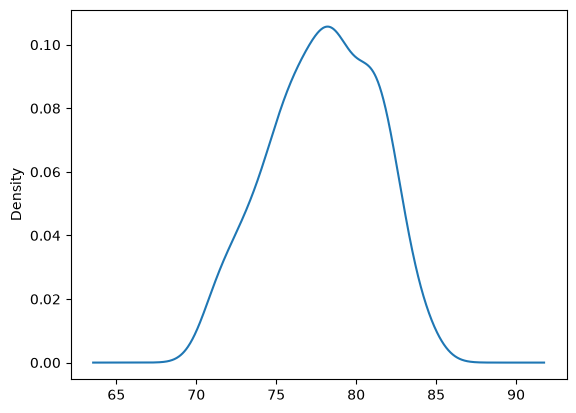

In [25]:
healthexp.Life_Expectancy.plot.kde()
plt.show()

Notice how it is a smoothed version of the histogram.

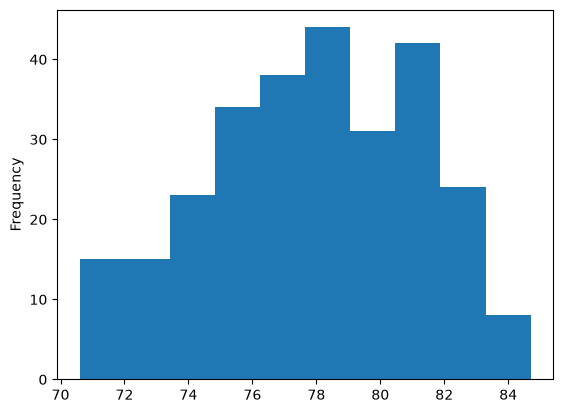

In [72]:
healthexp.Life_Expectancy.plot.hist()
plt.show()

## Comparing two density plots

The domains of the x and y axes vary among variables for density plots.

To compare two plots, you can juxtapose them as follows.

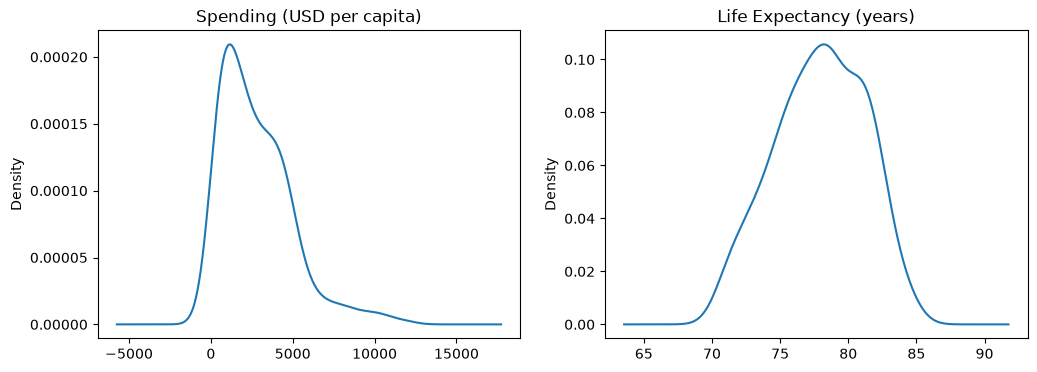

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
healthexp[['Spending_USD']].plot.kde(ax=ax[0], legend=Fdalse, title="Spending (USD per capita)")
healthexp[['Life_Expectancy']].plot.kde(ax=ax[1], legend=False, title="Life Expectancy (years)")
plt.show()

Or, using a more complex pattern, you can overlay them.

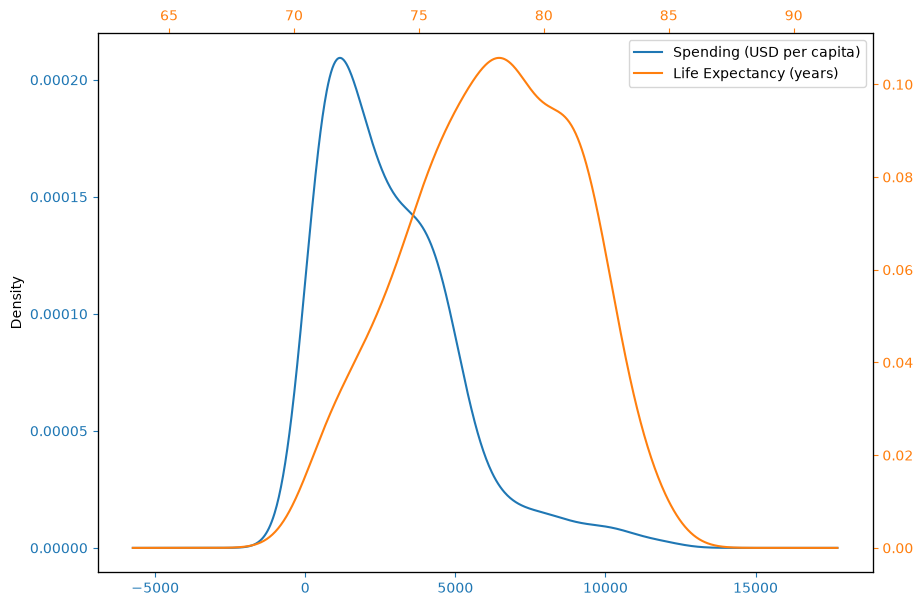

In [80]:
fig, ax1 = plt.subplots(figsize=(10,7))

ax_right = ax1.twinx()
ax2 = ax_right.twiny()

healthexp['Spending_USD'].plot.kde(ax=ax1, color='tab:blue', label="Spending (USD per capita)", legend=False)
healthexp['Life_Expectancy'].plot.kde(ax=ax2, color='tab:orange', label="Life Expectancy (years)", legend=False)

# pandas re-enables ax2's y-axis on the left, so we hide it and use ax_right instead
ax2.yaxis.set_visible(False)

# Align the colors of the ticks and spines for readability
ax1.tick_params(axis='x', colors='tab:blue')
ax1.tick_params(axis='y', colors='tab:blue')
ax2.tick_params(axis='x', colors='tab:orange')
ax_right.tick_params(axis='y', colors='tab:orange')

# Combine the legends from both independent spaces
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

## Showing multiple groups

If we want to show how the density plots of countries differ, we first create a wide table that projects the domain of `country` onto axis 1.

In [81]:
life_exp_wide = healthexp.pivot(index='Year', columns='Country', values='Life_Expectancy')
life_exp_wide.head()

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0


Then we can plot it and Pandas will treat each column as a plot line.

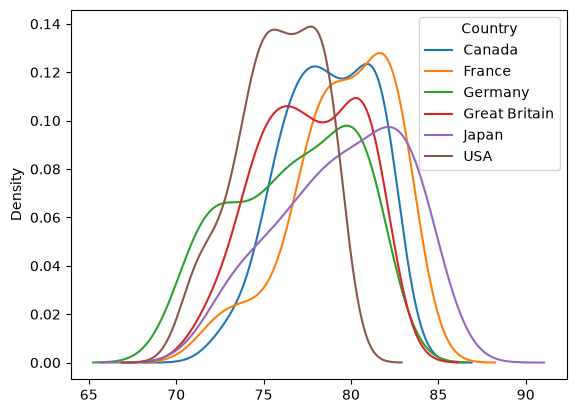

In [82]:
life_exp_wide.plot.kde()
plt.show()

You can color in the area under each curve by iterating through each line and applying the appropriate method.

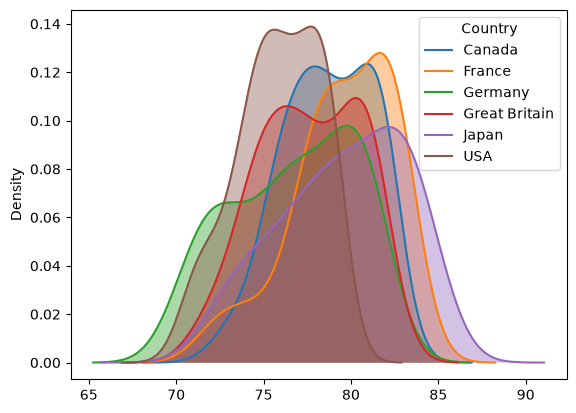

In [83]:
ax = life_exp_wide.plot.kde()
for line in ax.lines: 
    ax.fill_between(line.get_xdata(), line.get_ydata(), alpha=0.4)
plt.show()

> [!WARNING] The result looks something like an unstacked area chart.
>
> But in this case, you can't unstack the lines.
>
> This is because it doesn't make sense to add densities.

Pandas density plot method also supports the `subplots` argument.

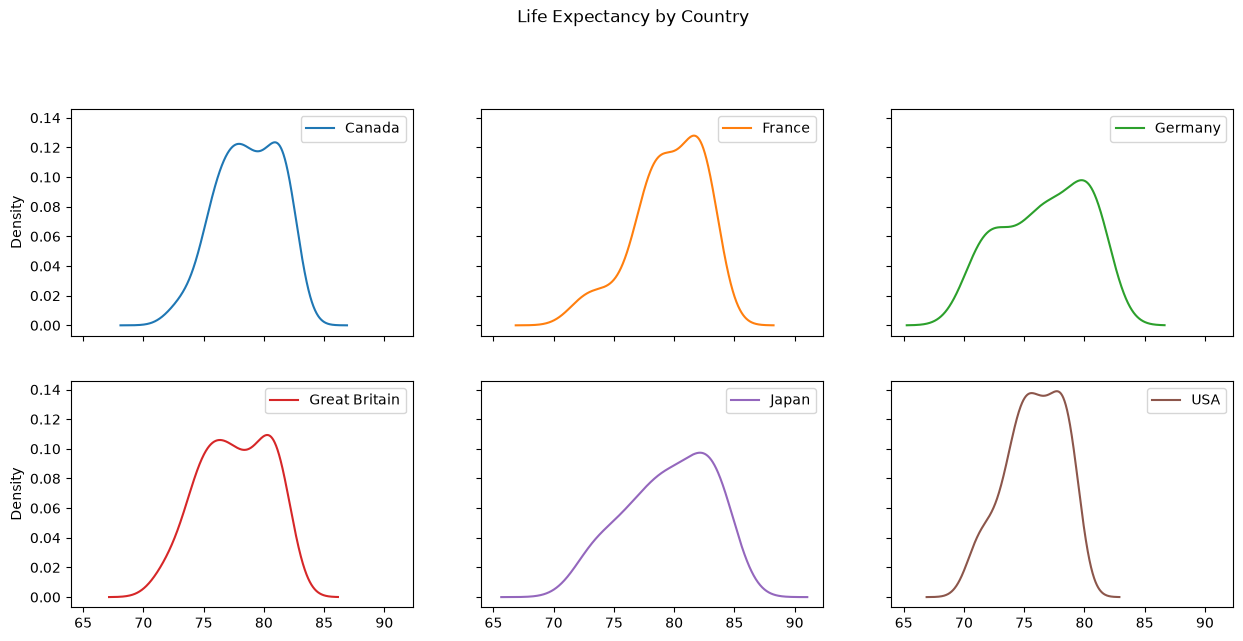

In [98]:
life_exp_wide.plot.kde(subplots=True, figsize=(15, 10), layout=(3,3), sharey=True)
plt.suptitle("Life Expectancy by Country")
plt.show()

## Using Seaborn

Seaborn's version of density plots has a simple argument to achieve the same effect.

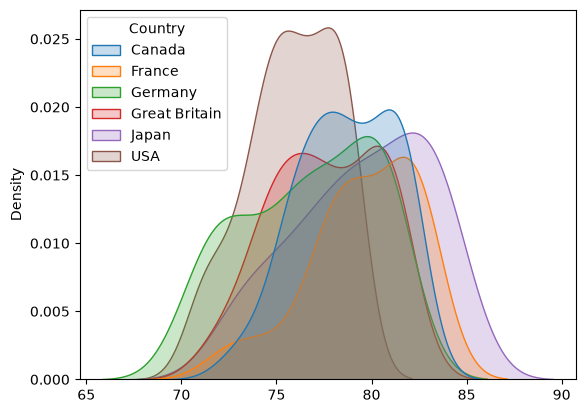

In [99]:
sns.kdeplot(life_exp_wide, fill=True)
plt.show()

Seaborn's version also allows you to by-pass having to pivot the tidy table. 

Instead of first setting the columns to `Country` in the pivot function, you can just set the `hue` (i.e. color) to `Country`.

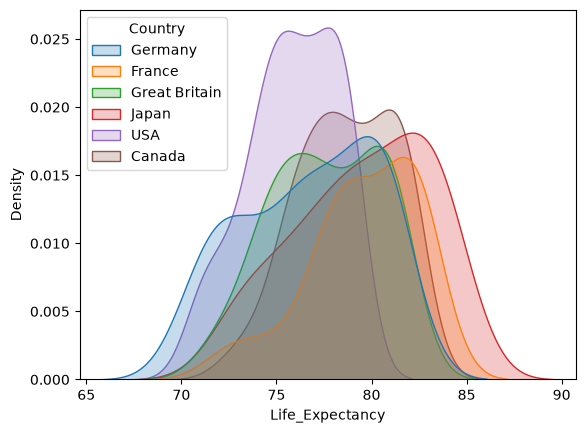

In [110]:
sns.kdeplot(healthexp, x='Life_Expectancy', hue='Country', fill=True)
plt.show()

> [!CAUTION] Although by-passing the need to widen the table is convenient, it also violates the design pattern of shaping your data as part of the visualization pipeline.

## Combining histograms and density plots

Sometimes we want to hedge our bets and show both histograms and density plots at the same time.

One way to do this is to set `density = True` on the histogram and then plot both an the same axes object.

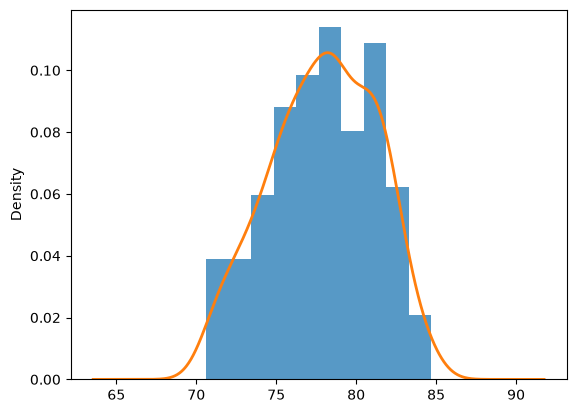

In [111]:
healthexp.Life_Expectancy.plot.hist(density=True, alpha=.75)
healthexp.Life_Expectancy.plot.kde(lw=2)
plt.show()

Another pattern is to use `ax.twinx()`, as we did in our lesson on Line Graphs.

This preserves the y axis domains of both plots.

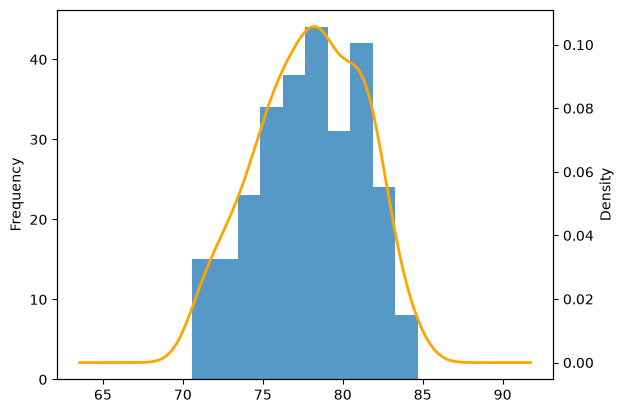

In [117]:
ax1 = healthexp.Life_Expectancy.plot.hist(alpha=.75)
ax2 = ax1.twinx()
healthexp.Life_Expectancy.plot.kde(ax=ax2, color='orange', lw=2)
plt.show()

Note, however, the misalignment of the two axes. Even though they represent different domains, they should align at $0$.

Because density plots can be negative, the plotting function left some room for that.

To align the two axes, we force both y axes to be use $0$ as their bottom value.

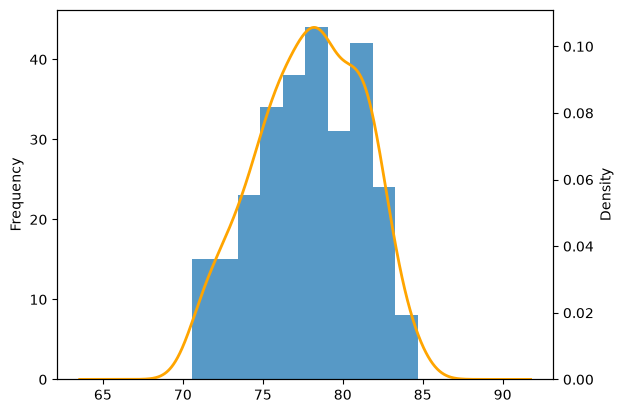

In [116]:
ax1 = healthexp.Life_Expectancy.plot.hist(alpha=.75)
ax2 = ax1.twinx()
healthexp.Life_Expectancy.plot.kde(ax=ax2, color='orange', lw=2)

# These settings prevent a gap on the bottom
ax1.set_ylim(bottom=0) 
ax2.set_ylim(bottom=0)

plt.show()